# Phase 1.6 — Exploratory Data Analysis

**Project:** Victoria Rental Stress Forecasting
**Author:** Daniel Niaragh
**Date:** May 2026

---

## Purpose of this notebook

By the end of Phase 1 we have four cleaned, joinable datasets sitting in `data/processed/` and `data/reference/`:

| Dataset | File | Rows | Coverage |
|---|---|---|---|
| DFFH quarterly rents | `dffh_lga_rents.parquet` | 40,340 | 1999-Q2 to 2025-Q3 |
| DFFH affordable lettings | `dffh_lga_affordability.parquet` | 39,390 | 2000-Q1 to 2025-Q3 |
| ABS Census 2021 household income | `abs_lga_income.parquet` | 79 | 2021 snapshot |
| ABS LGA boundaries | `vic_lga_boundaries.geojson` | 79 | 2021 vintage |

Before we start building features and models in Phase 2, we need to **look at the data**.

This notebook answers five questions:

1. **Coverage and completeness:** Which LGAs and quarters have data? Where are the gaps?
2. **What does rent look like?** Distribution today, trends over time, regional patterns.
3. **What does income look like?** How does the cross-section compare to rent?
4. **What does rental stress look like?** Computing our first stress estimates, choosing a definition.
5. **What does the official affordability story tell us?** DFFH's own measure of affordable lettings.

The findings here feed directly into Phase 2 decisions on feature engineering and the formal rental stress metric definition.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths (notebook lives in notebooks/, repo root is one level up)
REPO_ROOT = Path.cwd().parent
PROCESSED = REPO_ROOT / "data" / "processed"
REFERENCE = REPO_ROOT / "data" / "reference"

# Plotting defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

# Display defaults
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
rents = pd.read_parquet(PROCESSED / "dffh_lga_rents.parquet")
afford = pd.read_parquet(PROCESSED / "dffh_lga_affordability.parquet")
income = pd.read_parquet(PROCESSED / "abs_lga_income.parquet")

print(f"Rents:         {rents.shape[0]:>6,} rows x {rents.shape[1]} cols")
print(f"Affordability: {afford.shape[0]:>6,} rows x {afford.shape[1]} cols")
print(f"Income:        {income.shape[0]:>6,} rows x {income.shape[1]} cols")

Rents:         40,976 rows x 6 cols
Affordability: 39,895 rows x 5 cols
Income:            79 rows x 22 cols


## 1. Coverage and completeness

Before any modelling, we need to understand the *shape* of the data. Government rental data has known quirks: small LGAs get cells suppressed when there are too few bonds to publish without compromising confidentiality, and property types are not equally available across all LGAs.

### 1.1 What LGAs and quarters does each dataset cover?

In [3]:
print("=== Time coverage ===")
print(f"Rents:         {rents['quarter'].min()} -> {rents['quarter'].max()} "
      f"({rents['quarter'].nunique()} quarters)")
print(f"Affordability: {afford['quarter'].min()} -> {afford['quarter'].max()} "
      f"({afford['quarter'].nunique()} quarters)")

print(f"\n=== LGA counts ===")
print(f"Rents:         {rents['lga'].nunique()} unique LGAs")
print(f"Affordability: {afford['lga'].nunique()} unique LGAs")
print(f"Income:        {income['lga'].nunique()} unique LGAs")

# Sanity: do all three datasets reference the same LGAs?
rent_lgas = set(rents['lga'].unique())
afford_lgas = set(afford['lga'].unique())
income_lgas = set(income['lga'].unique())

print(f"\n=== Join compatibility ===")
print(f"Rents \\u2229 Income: {len(rent_lgas & income_lgas)}")
print(f"Rents \\u2229 Affordability: {len(rent_lgas & afford_lgas)}")
print(f"All three:         {len(rent_lgas & afford_lgas & income_lgas)}")

=== Time coverage ===
Rents:         1999-Q2 -> 2025-Q3 (106 quarters)
Affordability: 2000-Q1 -> 2025-Q3 (101 quarters)

=== LGA counts ===
Rents:         79 unique LGAs
Affordability: 79 unique LGAs
Income:        79 unique LGAs

=== Join compatibility ===
Rents \u2229 Income: 79
Rents \u2229 Affordability: 79
All three:         79


**Finding:** All three datasets reference identical sets of LGAs after Phase 1.4's name normalisation work. Joins will not silently drop rows. This is exactly the kind of upfront alignment that pays off compounding interest later — we don't have to think about LGA naming again.

### 1.2 Property type coverage per LGA

DFFH suppresses bond counts below a threshold for privacy. Small rural LGAs may have very few quarters of 2-bed-flat data, even though they have plenty of 3-bed-house data. We need to know which LGA × property-type combinations are dense enough to model.

In [4]:
coverage = (
    rents.groupby(['lga', 'property_type'])['quarter']
    .nunique()
    .unstack(fill_value=0)
)
print(f"Per-LGA per-property-type quarter counts:")
print(f"  Min:    {coverage.values.min()} quarters")
print(f"  Median: {int(np.median(coverage.values))} quarters")
print(f"  Max:    {coverage.values.max()} quarters (full series = 106)")
print(f"  LGAs with all 6 property types having 100+ quarters: "
      f"{(coverage.min(axis=1) >= 100).sum()} / {len(coverage)}")

Per-LGA per-property-type quarter counts:
  Min:    0 quarters
  Median: 106 quarters
  Max:    106 quarters (full series = 106)
  LGAs with all 6 property types having 100+ quarters: 35 / 79


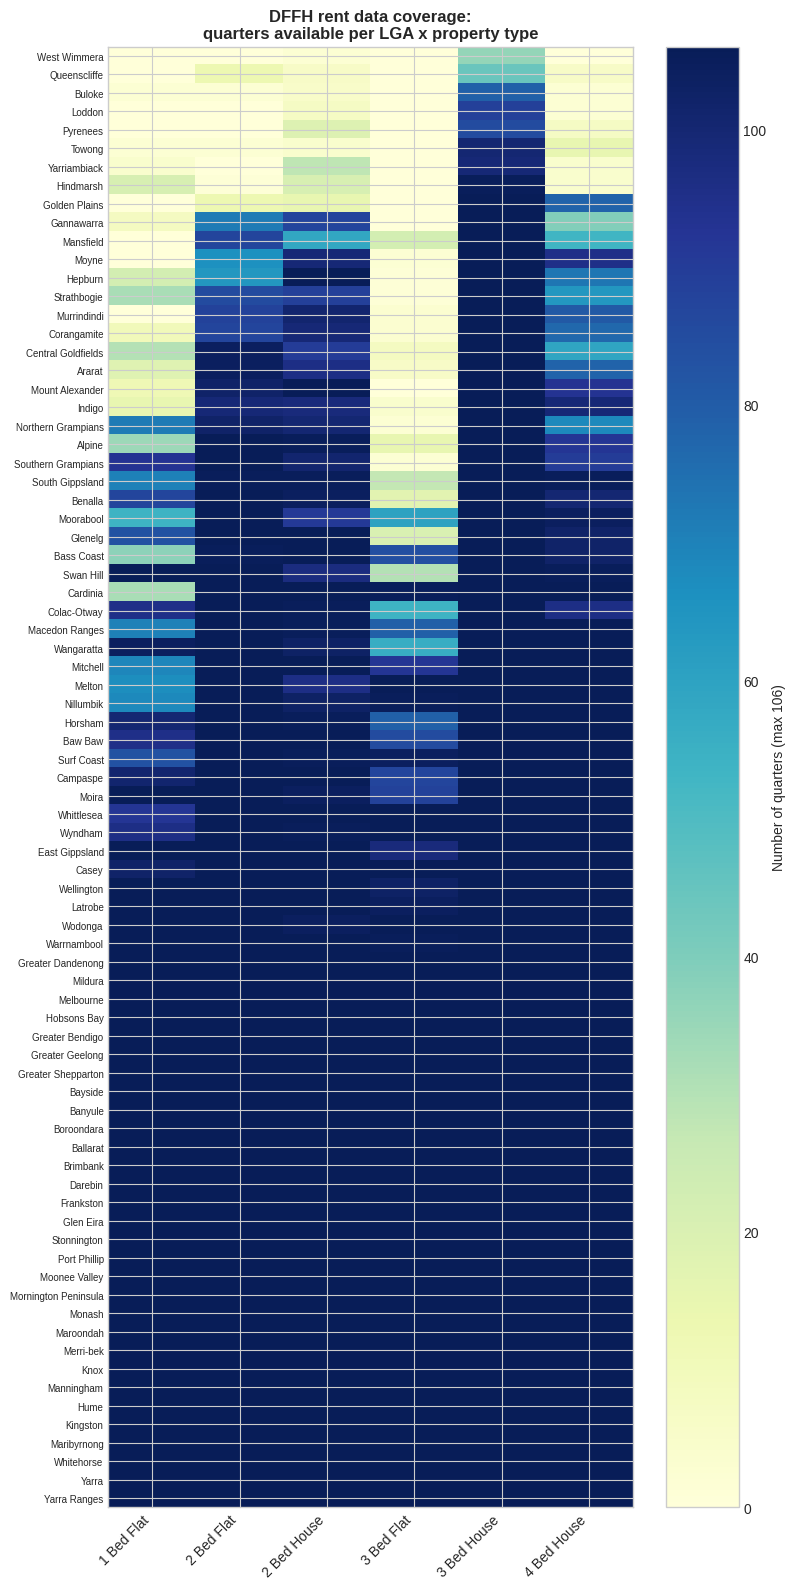

In [5]:
# Heat-map of coverage: rows = LGA (sorted by total), cols = property type
coverage_sorted = coverage.assign(total=coverage.sum(axis=1)).sort_values('total').drop(columns='total')

fig, ax = plt.subplots(figsize=(8, 16))
im = ax.imshow(coverage_sorted.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=106)
ax.set_xticks(range(len(coverage_sorted.columns)))
ax.set_xticklabels(coverage_sorted.columns, rotation=45, ha='right')
ax.set_yticks(range(len(coverage_sorted.index)))
ax.set_yticklabels(coverage_sorted.index, fontsize=7)
ax.set_title('DFFH rent data coverage:\nquarters available per LGA x property type', fontsize=12)
plt.colorbar(im, ax=ax, label='Number of quarters (max 106)')
plt.tight_layout()
plt.show()

**Finding:** Coverage is highly uneven. Urban LGAs have near-full coverage across all 6 property types. Many rural LGAs only have meaningful data for 2- and 3-bed houses.

**Implication for Phase 2:** The forecasting model will need to handle this. Options:
- Restrict to LGA × property-type combinations with at least ~80 quarters (sufficient for time-series modelling)
- Fall back to regional aggregates for sparse LGAs
- Use a multi-task / hierarchical model that pools weakly across related LGAs

A decision to be made in Phase 2.

## 2. What does rent look like?

We'll focus on **2-bedroom flats** as the analytical reference property type. It's the most common urban housing unit, has the broadest LGA coverage among flat types, and is the closest match for the household composition (singles, couples, single parents with one child) that DFFH uses in its own affordability methodology.

### 2.1 Long-run trends — selected LGAs

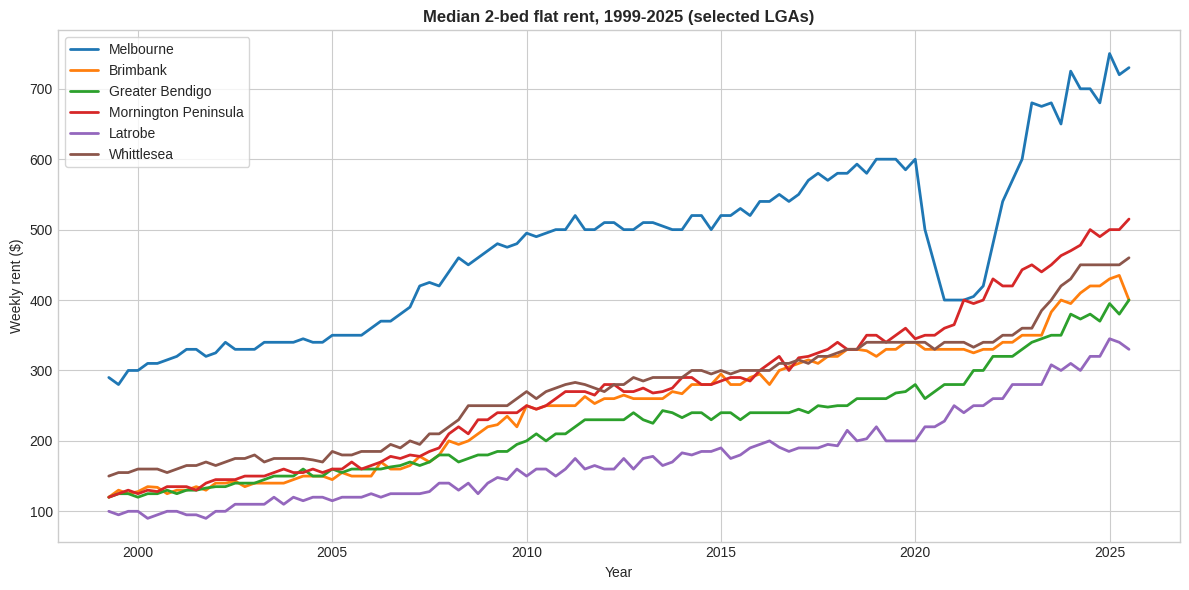

In [6]:
def quarter_to_x(q: str) -> float:
    '''Convert quarter string YYYY-QN to a float year for plotting.'''
    return int(q[:4]) + (int(q[6]) - 1) * 0.25


focus_lgas = [
    'Melbourne', 'Brimbank', 'Greater Bendigo',
    'Mornington Peninsula', 'Latrobe', 'Whittlesea'
]

fig, ax = plt.subplots(figsize=(12, 6))
for lga in focus_lgas:
    s = (
        rents[(rents['lga'] == lga) & (rents['property_type'] == '2 Bed Flat')]
        .sort_values('quarter')
        .copy()
    )
    s['x'] = s['quarter'].apply(quarter_to_x)
    ax.plot(s['x'], s['median_weekly_rent'], label=lga, lw=2)

ax.set_title('Median 2-bed flat rent, 1999-2025 (selected LGAs)')
ax.set_xlabel('Year')
ax.set_ylabel('Weekly rent ($)')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

**Findings worth noting:**

- **Melbourne LGA** (inner city) shows the famous COVID rent dip in 2020-21 — international students left, vacancy rates spiked, rents fell ~30%. They have since recovered fully.
- **Mornington Peninsula** has been the strongest long-run grower, almost tripling over 26 years. Sea-change demographics playing out in data.
- **Brimbank and Greater Bendigo** had nearly identical 2-bed flat rents in 1999 ($120/week). They've stayed roughly together through to 2025 ($400/week each), even though one is a working-class metro LGA and the other is a regional centre.
- **Latrobe** has been the slowest grower among the sample, reflecting weak economic conditions in the Latrobe Valley over much of this period.

### 2.2 Cross-sectional distribution — most recent quarter

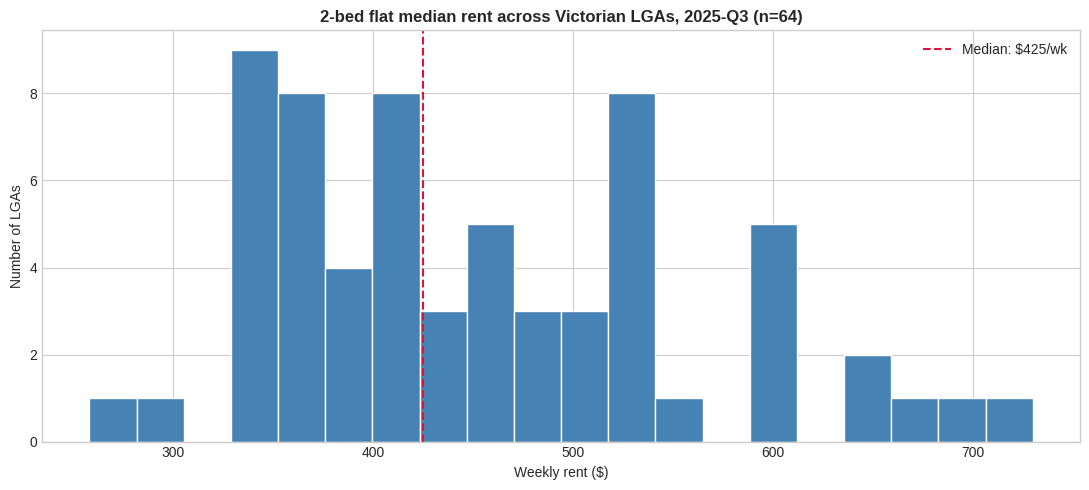


Top and bottom 5 LGAs by 2-bed flat rent (2025-Q3):
         lga  median_weekly_rent
   Melbourne              730.00
       Yarra              700.00
 Stonnington              675.00
     Bayside              650.00
Port Phillip              650.00
...
               lga  median_weekly_rent
Northern Grampians              258.00
           Glenelg              305.00
           Latrobe              330.00
            Ararat              340.00
Central Goldfields              340.00


In [7]:
latest = (
    rents[(rents['quarter'] == '2025-Q3') & (rents['property_type'] == '2 Bed Flat')]
    .dropna(subset=['median_weekly_rent'])
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(latest['median_weekly_rent'], bins=20, color='steelblue', edgecolor='white')
ax.axvline(latest['median_weekly_rent'].median(), color='crimson', linestyle='--',
           label=f"Median: ${latest['median_weekly_rent'].median():.0f}/wk")
ax.set_title(f'2-bed flat median rent across Victorian LGAs, 2025-Q3 (n={len(latest)})')
ax.set_xlabel('Weekly rent ($)')
ax.set_ylabel('Number of LGAs')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop and bottom 5 LGAs by 2-bed flat rent (2025-Q3):")
print(latest.nlargest(5, 'median_weekly_rent')[['lga', 'median_weekly_rent']].to_string(index=False))
print("...")
print(latest.nsmallest(5, 'median_weekly_rent')[['lga', 'median_weekly_rent']].to_string(index=False))

**Finding:** The distribution is roughly bimodal — a cluster of regional LGAs around $300-400/week, then a sparser tail of inner-Melbourne LGAs running up to $730/week. The gap reflects metro/non-metro housing market segmentation that persists through the time series.

### 2.3 5-year growth rates by LGA

Where has rent moved most over the post-COVID period?

In [8]:
recent = rents[
    (rents['property_type'] == '2 Bed Flat')
    & (rents['quarter'].isin(['2020-Q3', '2025-Q3']))
]
piv = recent.pivot(index='lga', columns='quarter', values='median_weekly_rent').dropna()
piv['pct_5yr'] = (piv['2025-Q3'] / piv['2020-Q3'] - 1) * 100

print(f"=== Top 10 fastest-growing LGAs, 2-bed flat rent, 2020-Q3 -> 2025-Q3 ===")
print(piv.nlargest(10, 'pct_5yr').to_string())
print(f"\n=== Slowest growers ===")
print(piv.nsmallest(5, 'pct_5yr').to_string())

=== Top 10 fastest-growing LGAs, 2-bed flat rent, 2020-Q3 -> 2025-Q3 ===
quarter             2020-Q3  2025-Q3  pct_5yr
lga                                          
Wodonga              253.00   415.00    64.03
Campaspe             245.00   400.00    63.27
Greater Shepparton   245.00   400.00    63.27
Melbourne            450.00   730.00    62.22
Moira                235.00   380.00    61.70
Southern Grampians   215.00   345.00    60.47
Mitchell             250.00   398.00    59.20
Benalla              240.00   375.00    56.25
Wangaratta           235.00   360.00    53.19
Indigo               258.00   395.00    53.10

=== Slowest growers ===
quarter      2020-Q3  2025-Q3  pct_5yr
lga                                   
Glenelg       260.00   305.00    17.31
Moorabool     300.00   355.00    18.33
Brimbank      330.00   400.00    21.21
Colac-Otway   293.00   370.00    26.28
Wyndham       320.00   410.00    28.12


**Findings:**

- Top 10 fastest-rising LGAs are mostly *regional* — Wodonga, Campaspe, Greater Shepparton, Moira, Benalla. The post-COVID regional shift shows clearly in the data.
- The Melbourne LGA is in the top 5, but that's because it's bouncing back from the deep COVID dip, not because it's exceptionally hot now.
- Outer-metro and metro-fringe LGAs (Brimbank, Wyndham) grew more slowly — these are areas with newer housing supply absorbing demand.

## 3. What does income look like?

Income is our denominator for rental stress. We have one snapshot (2021 Census) at LGA level, with both median household income and 25th percentile income computed from the binned distribution.

In [9]:
print(f"=== Median household income (weekly, 2021) ===")
print(f"  Range: ${income['median_weekly_household_income'].min():.0f} - "
      f"${income['median_weekly_household_income'].max():.0f}")
print(f"  Median LGA: ${income['median_weekly_household_income'].median():.0f}")

print(f"\n=== Lower-quartile household income (p25, weekly, 2021) ===")
print(f"  Range: ${income['p25_weekly_household_income'].min():.0f} - "
      f"${income['p25_weekly_household_income'].max():.0f}")
print(f"  Median LGA: ${income['p25_weekly_household_income'].median():.0f}")

=== Median household income (weekly, 2021) ===
  Range: $906 - $2487
  Median LGA: $1449

=== Lower-quartile household income (p25, weekly, 2021) ===
  Range: $512 - $1320
  Median LGA: $778


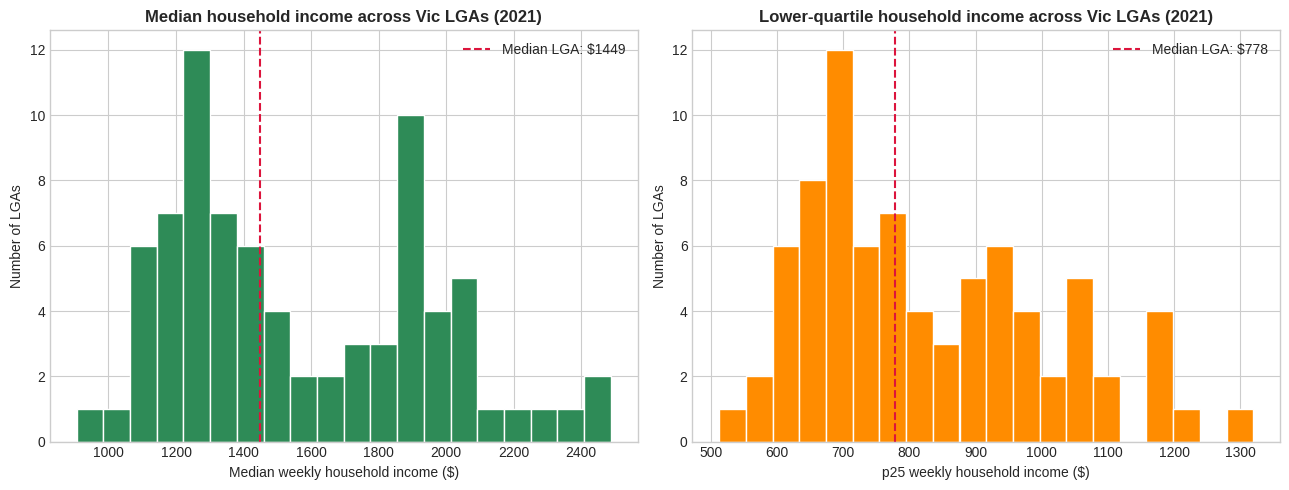


Most affluent LGAs by median income:
        lga  median_weekly_household_income  p25_weekly_household_income
    Bayside                        2,487.50                     1,163.80
  Nillumbik                        2,476.46                     1,319.80
 Boroondara                        2,376.05                     1,209.97
      Yarra                        2,270.23                     1,198.21
Stonnington                        2,209.42                     1,179.70

Lowest income LGAs:
               lga  median_weekly_household_income  p25_weekly_household_income
Central Goldfields                          905.70                       512.45
            Loddon                        1,039.95                       563.33
        Gannawarra                        1,068.98                       602.92
            Buloke                        1,087.57                       605.27
          Pyrenees                        1,097.99                       587.82


In [10]:
# Visualise the income distribution across LGAs
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(income['median_weekly_household_income'], bins=20, color='seagreen', edgecolor='white')
axes[0].axvline(income['median_weekly_household_income'].median(), color='crimson', linestyle='--',
                label=f"Median LGA: ${income['median_weekly_household_income'].median():.0f}")
axes[0].set_title('Median household income across Vic LGAs (2021)')
axes[0].set_xlabel('Median weekly household income ($)')
axes[0].set_ylabel('Number of LGAs')
axes[0].legend()

axes[1].hist(income['p25_weekly_household_income'], bins=20, color='darkorange', edgecolor='white')
axes[1].axvline(income['p25_weekly_household_income'].median(), color='crimson', linestyle='--',
                label=f"Median LGA: ${income['p25_weekly_household_income'].median():.0f}")
axes[1].set_title('Lower-quartile household income across Vic LGAs (2021)')
axes[1].set_xlabel('p25 weekly household income ($)')
axes[1].set_ylabel('Number of LGAs')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMost affluent LGAs by median income:")
print(income.nlargest(5, 'median_weekly_household_income')[
    ['lga', 'median_weekly_household_income', 'p25_weekly_household_income']
].to_string(index=False))
print(f"\nLowest income LGAs:")
print(income.nsmallest(5, 'median_weekly_household_income')[
    ['lga', 'median_weekly_household_income', 'p25_weekly_household_income']
].to_string(index=False))

**Finding:** Inner-eastern Melbourne LGAs (Bayside, Boroondara, Nillumbik) cluster at the top. Western Victorian rural LGAs (Central Goldfields, Loddon, Gannawarra) sit at the bottom. The spread between top and bottom is ~3x for median income, ~3x for p25 income — consistent ratios across the income distribution.

## 4. Rental stress — first estimates and definitional decisions

We can now combine rent and income to compute our first rental stress numbers.

Our working definition (from `methodology.md` Section 3) is:

> rental_stress_ratio = median_weekly_rent / median_weekly_household_income

with a 30% threshold flagging a household as "stressed."

Three definitional choices we need to test:

1. **Which income reference?** Median income, or 25th-percentile (lower-quartile) income? The latter is more sensitive for the population most exposed to rental stress.
2. **Which rent reference?** Median rent for 2-bed flat, or weighted average across property types?
3. **Which threshold?** 30% is standard; 50% is often used to flag "severe" stress.

### 4.1 Computing stress with median vs p25 income

In [11]:
# Latest 2-bed flat rents, joined to income
latest_rent = (
    rents[(rents['quarter'] == '2025-Q3') & (rents['property_type'] == '2 Bed Flat')]
    .dropna(subset=['median_weekly_rent'])
)
stress = latest_rent.merge(
    income[['lga', 'median_weekly_household_income', 'p25_weekly_household_income']],
    on='lga',
    how='inner',
)
stress['stress_median_income'] = stress['median_weekly_rent'] / stress['median_weekly_household_income']
stress['stress_p25_income'] = stress['median_weekly_rent'] / stress['p25_weekly_household_income']

print(f"=== Distribution of stress ratios across {len(stress)} LGAs ===")
print(stress[['stress_median_income', 'stress_p25_income']].describe())

print(f"\n=== % LGAs above thresholds ===")
for thresh in [0.30, 0.40, 0.50]:
    med_above = (stress['stress_median_income'] > thresh).sum()
    p25_above = (stress['stress_p25_income'] > thresh).sum()
    print(f"  Threshold {int(thresh*100)}%: median-income stress {med_above:>2} LGAs, "
          f"p25-income stress {p25_above:>2} LGAs")

=== Distribution of stress ratios across 64 LGAs ===
       stress_median_income  stress_p25_income
count                 64.00              64.00
mean                   0.28               0.53
std                    0.04               0.08
min                    0.20               0.35
25%                    0.26               0.48
50%                    0.28               0.53
75%                    0.30               0.57
max                    0.44               0.85

=== % LGAs above thresholds ===
  Threshold 30%: median-income stress 16 LGAs, p25-income stress 64 LGAs
  Threshold 40%: median-income stress  1 LGAs, p25-income stress 60 LGAs
  Threshold 50%: median-income stress  0 LGAs, p25-income stress 42 LGAs


**Headline finding:** Using the standard 30% rental stress threshold and the **median** household income, only 16 of 63 Vic LGAs (~25%) are above the stress threshold for a 2-bed flat. Using the **lower-quartile** household income, *every single LGA* is above the threshold, and two-thirds are above 50% (severe stress).

This isn't a numerical artefact — it's a real statement about Victorian rental affordability:

> **For a low-income household, there is essentially no Victorian LGA where the median 2-bed flat is affordable.**

This is the most decision-relevant framing for our project and aligns with how policy makers actually think about housing stress. We'll lock in the p25 income reference as the primary stress denominator in Phase 2.

### 4.2 Scatter view: rent vs lower-quartile income

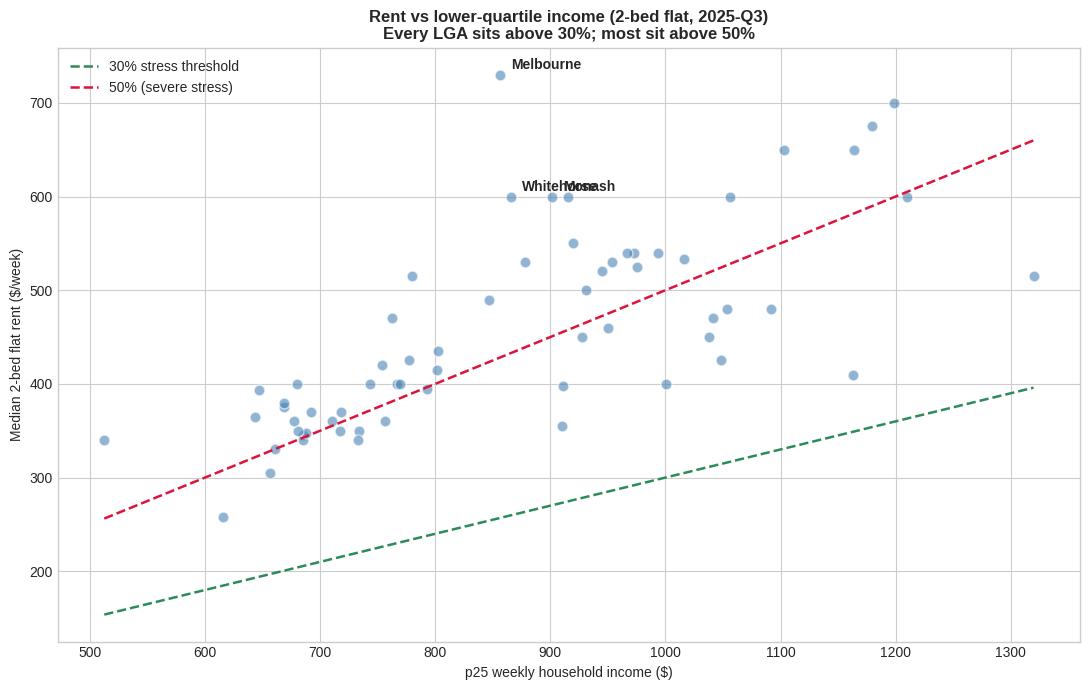

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(stress['p25_weekly_household_income'], stress['median_weekly_rent'],
           alpha=0.6, s=60, color='steelblue', edgecolor='white')

# Stress threshold lines
x_range = np.linspace(stress['p25_weekly_household_income'].min(),
                       stress['p25_weekly_household_income'].max(), 100)
ax.plot(x_range, 0.30 * x_range, '--', color='seagreen', label='30% stress threshold', lw=1.8)
ax.plot(x_range, 0.50 * x_range, '--', color='crimson', label='50% (severe stress)', lw=1.8)

# Highlight outliers
for _, row in stress.nlargest(3, 'stress_p25_income').iterrows():
    ax.annotate(row['lga'],
                xy=(row['p25_weekly_household_income'], row['median_weekly_rent']),
                xytext=(8, 4), textcoords='offset points', fontsize=10, weight='bold')

ax.set_title('Rent vs lower-quartile income (2-bed flat, 2025-Q3)\n'
             'Every LGA sits above 30%; most sit above 50%')
ax.set_xlabel('p25 weekly household income ($)')
ax.set_ylabel('Median 2-bed flat rent ($/week)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 5. The official affordability story

DFFH publishes its own affordability measure: the **share of new rentals affordable to indicative households on income-support payments** (e.g. single on JobSeeker, parent on Parenting Payment). This is a stricter and more policy-relevant definition than the 30% rule, because it's grounded in real welfare payment amounts.

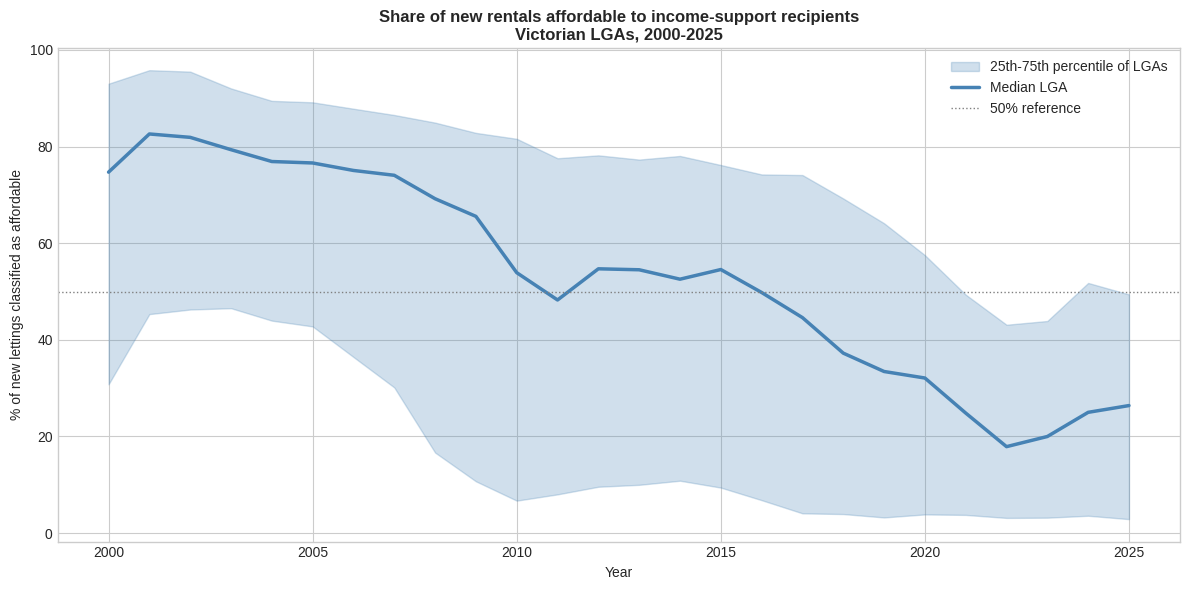

In [13]:
# Use 'All Bedrooms' rollup for the headline
all_beds = afford[afford['bedroom_category'] == 'All Bedrooms'].copy()
all_beds['year'] = all_beds['quarter'].str[:4].astype(int)

# Yearly statewide trend
yearly = all_beds.groupby('year')['affordable_pct'].agg(
    p25=lambda s: s.quantile(0.25),
    p50='median',
    p75=lambda s: s.quantile(0.75),
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(yearly.index, yearly['p25'] * 100, yearly['p75'] * 100,
                alpha=0.25, color='steelblue', label='25th-75th percentile of LGAs')
ax.plot(yearly.index, yearly['p50'] * 100, color='steelblue', lw=2.5, label='Median LGA')
ax.axhline(50, color='gray', linestyle=':', lw=1, label='50% reference')

ax.set_title('Share of new rentals affordable to income-support recipients\n'
             'Victorian LGAs, 2000-2025')
ax.set_xlabel('Year')
ax.set_ylabel('% of new lettings classified as affordable')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

**The headline statistic:**

- In 2000, the median Victorian LGA had **75%** of new lettings affordable to income-support recipients.
- By 2025, that figure is **27%**.

This is a structural transformation, not a fluctuation. The shaded band (25th-75th percentile of LGAs) also collapses inward over time, meaning the decline is broad — not driven by a few extreme LGAs.

In [14]:
# Which LGAs have changed most over the period?
afford_pivot = (
    all_beds[all_beds['quarter'].isin(['2005-Q1', '2025-Q3'])]
    .pivot(index='lga', columns='quarter', values='affordable_pct')
    .dropna()
)
afford_pivot['drop_pts'] = (afford_pivot['2005-Q1'] - afford_pivot['2025-Q3']) * 100

print(f"=== LGAs where affordable share dropped most, 2005 -> 2025 (percentage points) ===")
print(afford_pivot.nlargest(10, 'drop_pts').round(3).to_string())

=== LGAs where affordable share dropped most, 2005 -> 2025 (percentage points) ===
quarter            2005-Q1  2025-Q3  drop_pts
lga                                          
Casey                 0.77     0.03     73.90
Cardinia              0.79     0.05     73.70
Greater Dandenong     0.75     0.02     73.10
Baw Baw               0.83     0.14     68.70
Frankston             0.70     0.02     68.20
Indigo                0.81     0.14     67.40
Mansfield             0.78     0.13     65.40
Macedon Ranges        0.69     0.05     64.00
Mount Alexander       0.75     0.12     63.70
Strathbogie           0.91     0.28     63.20


## 6. First map view

To validate the full pipeline visually — boundaries + rents + income, all joined — render a choropleth of current rental stress across Victoria.

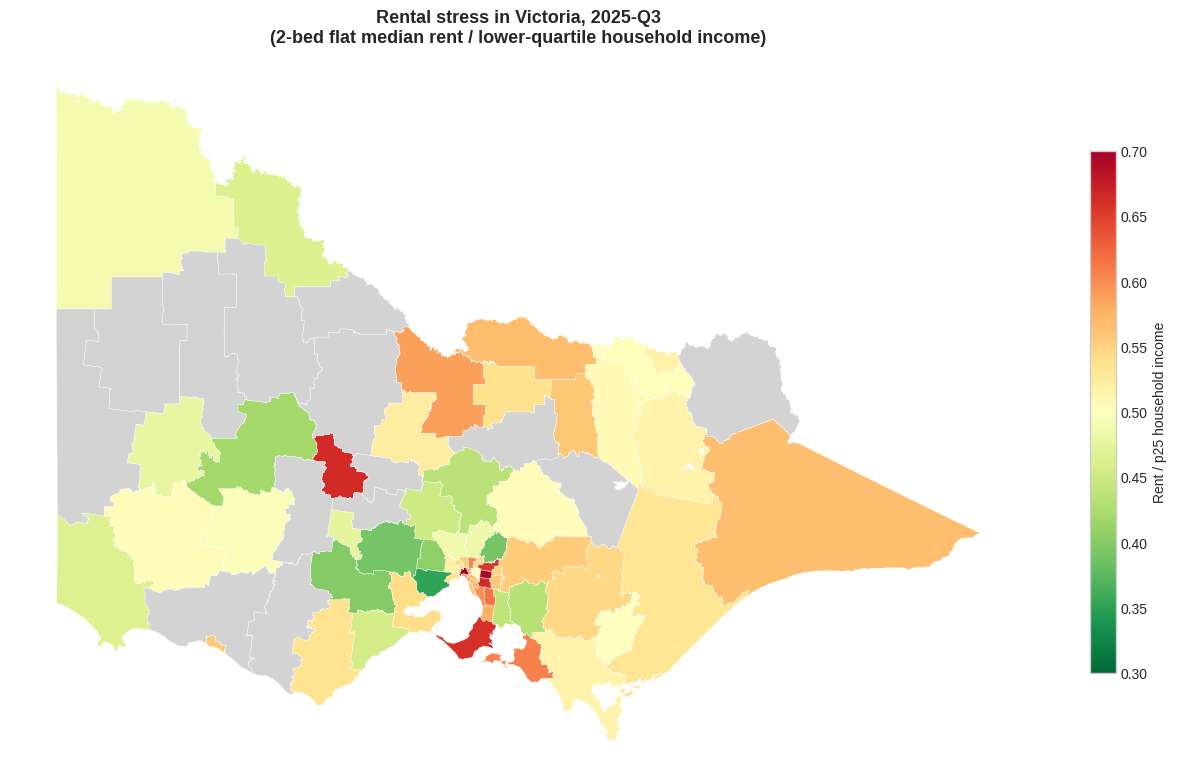

In [15]:
import geopandas as gpd

boundaries = gpd.read_file(REFERENCE / 'vic_lga_boundaries.geojson')
merged = boundaries.merge(
    stress[['lga', 'stress_p25_income']], on='lga', how='left'
)

fig, ax = plt.subplots(figsize=(13, 9))
merged.plot(
    column='stress_p25_income',
    ax=ax,
    cmap='RdYlGn_r',
    vmin=0.3,
    vmax=0.7,
    legend=True,
    legend_kwds={'label': 'Rent / p25 household income', 'shrink': 0.6},
    missing_kwds={'color': 'lightgray', 'label': 'No data'},
    edgecolor='white',
    linewidth=0.3,
)
ax.set_title(
    'Rental stress in Victoria, 2025-Q3\n'
    '(2-bed flat median rent / lower-quartile household income)',
    fontsize=13
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

**The full pipeline works end-to-end.** This is the first time we've seen the rents, income, and boundary data combined into a single view.

Read this map:
- **Green** = lower stress (rent affordable to ~40% or less of p25 household income)
- **Red** = severe stress (rent consuming >60% of p25 household income)
- **Grey** = no published 2-bed-flat data for that LGA in 2025-Q3

The hot zone around inner Melbourne and the Mornington Peninsula is exactly where it should be. Grey LGAs are mostly small rural councils with insufficient bond data — the modelling subset decision in 6.2 above will need to handle these.

This map is essentially the first frame of what the dashboard will show interactively across all 106 quarters and all 6 property types — but already, in static form, it tells a clear story.

## 7. Summary: decisions feeding Phase 2

Three decisions that shape the rest of the project, derived from the data:

### 7.1 Stress metric definition

**Lock in p25 (lower-quartile) household income as the denominator.** Using the median income makes the rental stress signal too weak to be informative — only a quarter of LGAs flagged as stressed, none at the severe level. Using p25 reveals what's actually happening at the affected end of the housing market.

### 7.2 Modelling subset

**Model LGA x property-type series with at least 80 quarters of data.** Sparser series will be either dropped from training or imputed from regional aggregates — final approach decided in Phase 2.

### 7.3 Target variable choice

Two viable targets emerge:

1. **The DFFH-style affordability percentage** — share of new lettings affordable. This has the advantage of being an officially-recognised metric and the time series is already in `dffh_lga_affordability.parquet`. Forecasting it produces directly interpretable headlines ("X% of new rentals will be affordable in Q3 2026").

2. **Our computed rent / p25-income stress ratio** — purely income-relative measure. More volatile but more flexible analytically.

**Recommendation:** Forecast both. The DFFH measure is the policy-relevant headline; our stress ratio is the model-internal mechanism. They complement each other.

### 7.4 What remains for the methodology document

The methodology entries already written for Phases 1.2-1.5 cover data sources, parsing decisions, and known limitations. Phase 2 will need to add:

- Final stress-metric definition and rationale (replacing the working Section 3)
- Treatment of sparse LGA x property-type combinations
- Pandemic-era anomaly handling (Melbourne 2020-21 rent collapse is real signal, not error)
- Decision on multi-horizon forecast targets (1Q vs 4Q ahead)

These decisions are made in Phase 2 once feature engineering begins.

## End of Phase 1

Phase 1 is now complete. The repository state:

- **4 cleaned data sources** in `data/processed/` and `data/reference/`
- **4 production parsers** with smoke-test coverage in `src/ingestion/`
- **4 ingestion scripts** for reproducibility in `scripts/`
- **35+ smoke tests** including cross-dataset join compatibility
- **Methodology document** with sourcing decisions and limitations explicitly recorded
- **This notebook** capturing the analytical posture going into Phase 2

Next phase: feature engineering, formal rental stress metric construction, and the target variable design for modelling.